### Option 1: Using our `simple_disparity_xg_ratio.csv`.
Path to disparity metrics derived from simple xg_ratios.

### Paths:
1. `WHL-2026/src/phase1/b/direct-xg/simple_disparity_xg_ratio.csv` - Path to disparity metrics derived from simple xg_ratios.
2. `WHL-2026/src/data/b/team_disparity.csv` - Path to disparity ratios derived from generated ELO's for each line.

### For our team_elo csv:
Find `WHL-2026/src/data/a/power_rankings.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from pathlib import Path

rel_path = Path.cwd().parent.parent.parent
src_path_disparity = rel_path / "phase1" / "b" / "direct-xg" / "simple_disparity_xg_ratio.csv"

# relative path for power rankings
src_path_elos = rel_path / "data" / "a" / "power_rankings.csv"

xg_rankings_disparity = pd.read_csv(src_path_elos)
line_disparity = pd.read_csv(src_path_disparity)

# Merge
data = xg_rankings_disparity.merge(
    line_disparity[['team', 'disparity_ratio']],
    on='team'
)

# ── Verify merge ──────────────────────────────────────────────────────────────
print(f"Post-merge n = {len(data)}  (expected 32)")
assert len(data) == 32, f"WARNING: expected 32 rows, got {len(data)}"

# ── Data-driven tiers (tertiles) ──────────────────────────────────────────────
# pd.qcut splits into equal-sized groups (robust to data distribution).
# Fixed bins 1450/1550 are ±50 from the ELO starting value of 1500.
data['tier_qcut'], tier_bins = pd.qcut(
    data['elo'], q=3,
    labels=['Weak (bottom third)', 'Mid-Tier (middle third)', 'Elite (top third)'],
    retbins=True
)
print(f"\nData-driven tertile boundaries: {tier_bins.round(1).tolist()}")
print(data.groupby('tier_qcut', observed=True)['elo'].agg(['min', 'max', 'count']))

# Fixed bins retained for interpretability
data['category'] = pd.cut(
    data['elo'],
    bins=[0, 1450, 1550, 2000],
    labels=['Weak Teams\n(ELO < 1450)', 'Mid-Tier Teams\n(1450-1550)', 'Elite Teams\n(ELO > 1550)']
)

def sig_label(p):
    return "significant" if p < 0.05 else "not significant"

Post-merge n = 32  (expected 32)

Data-driven tertile boundaries: [1301.4, 1442.1, 1540.5, 1712.0]
                             min      max  count
tier_qcut                                       
Weak (bottom third)      1301.44  1437.76     11
Mid-Tier (middle third)  1450.72  1528.80     10
Elite (top third)        1546.32  1712.00     11


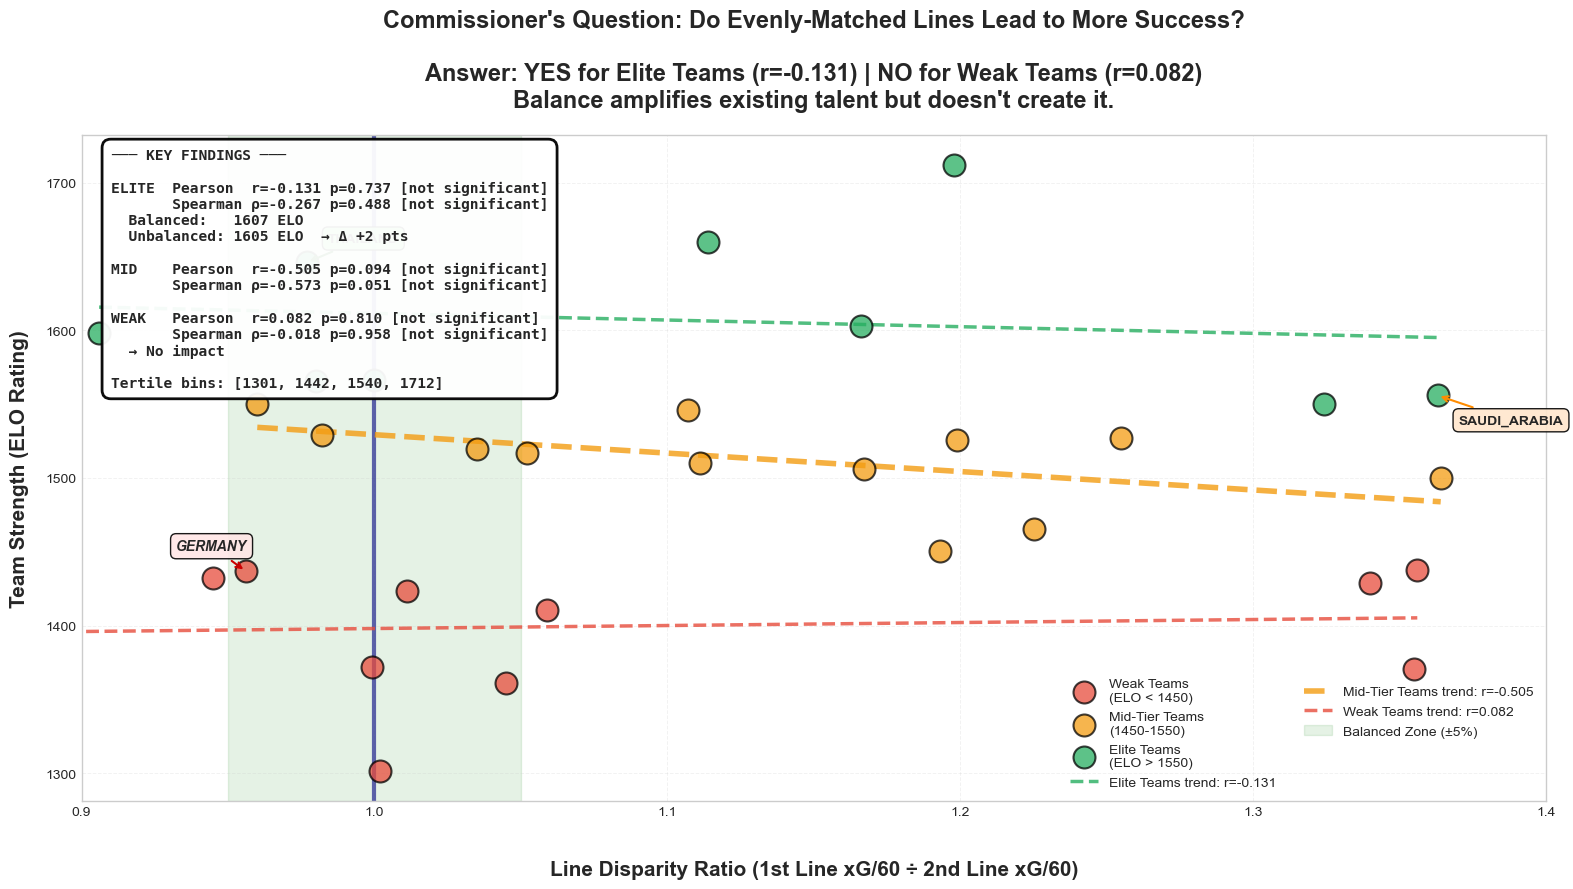


CORRELATION ANALYSIS BY TEAM TIER

ELITE TEAMS (ELO > 1550): Pearson r=-0.131 p=0.7367  [not significant]
                          Spearman ρ=-0.267 p=0.4879  [not significant]
  → Balanced teams average +2 ELO points higher

MID-TIER TEAMS (1450-1550): Pearson r=-0.505 p=0.0942  [not significant]
                            Spearman ρ=-0.573 p=0.0513  [not significant]

WEAK TEAMS (ELO < 1450):  Pearson r=0.082 p=0.8097  [not significant]
                          Spearman ρ=-0.018 p=0.9577  [not significant]
  → Balance doesn't matter for weak teams

RECOMMENDATION: Acquire talent first, then balance lines.


In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create figure
fig, ax = plt.subplots(figsize=(16, 9))

# Color map
colors = {
    'Weak Teams\n(ELO < 1450)': '#e74c3c',
    'Mid-Tier Teams\n(1450-1550)': '#f39c12',
    'Elite Teams\n(ELO > 1550)': '#27ae60'
}

# Scatter plot
for category in data['category'].cat.categories:
    subset = data[data['category'] == category]
    ax.scatter(
        subset['disparity_ratio'],
        subset['elo'],
        s=250,
        c=colors[category],
        alpha=0.75,
        edgecolors='black',
        linewidth=1.5,
        label=category,
        zorder=3
    )

# Tier subsets
elite = data[data['elo'] > 1550]
mid   = data[(data['elo'] >= 1450) & (data['elo'] <= 1550)]
weak  = data[data['elo'] < 1450]

# Pearson + Spearman correlations
corr_elite, p_elite = stats.pearsonr(elite['disparity_ratio'], elite['elo'])
corr_mid,   p_mid   = stats.pearsonr(mid['disparity_ratio'],   mid['elo'])
corr_weak,  p_weak  = stats.pearsonr(weak['disparity_ratio'],  weak['elo'])

sp_elite, sp_p_elite = stats.spearmanr(elite['disparity_ratio'], elite['elo'])
sp_mid,   sp_p_mid   = stats.spearmanr(mid['disparity_ratio'],   mid['elo'])
sp_weak,  sp_p_weak  = stats.spearmanr(weak['disparity_ratio'],  weak['elo'])

# Trend lines with correlation labels
for category, subset, corr, p_val in [
    ('Elite Teams\n(ELO > 1550)', elite, corr_elite, p_elite),
    ('Mid-Tier Teams\n(1450-1550)', mid, corr_mid, p_mid),
    ('Weak Teams\n(ELO < 1450)', weak, corr_weak, p_weak)
]:
    if len(subset) > 2:
        z = np.polyfit(subset['disparity_ratio'], subset['elo'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(subset['disparity_ratio'].min(),
                              subset['disparity_ratio'].max(), 100)
        linewidth = 4 if abs(corr) > 0.3 else 2.5
        ax.plot(x_trend, p(x_trend),
                color=colors[category],
                linestyle='--',
                linewidth=linewidth,
                alpha=0.8,
                zorder=2,
                label=f'{category.split("(")[0].strip()} trend: r={corr:.3f}')

# Reference line at perfect balance
ax.axvline(x=1.0, color='navy', linestyle='-', linewidth=3,
           alpha=0.6, zorder=1)
ax.axvspan(0.95, 1.05, alpha=0.1, color='green', zorder=0,
           label='Balanced Zone (±5%)')

# Annotations — 3 key teams
best_balanced_elite = elite[(elite['disparity_ratio'] >= 0.95) &
                            (elite['disparity_ratio'] <= 1.05)].nlargest(1, 'elo')
if not best_balanced_elite.empty:
    row = best_balanced_elite.iloc[0]
    ax.annotate(f"{row['team'].upper()}",
                (row['disparity_ratio'], row['elo']),
                xytext=(15, 15), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightgreen', alpha=0.9),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='darkgreen'))

worst_unbalanced_elite = elite.nlargest(1, 'disparity_ratio')
if not worst_unbalanced_elite.empty:
    row = worst_unbalanced_elite.iloc[0]
    ax.annotate(f"{row['team'].upper()}",
                (row['disparity_ratio'], row['elo']),
                xytext=(15, -20), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe6cc', alpha=0.9),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#ff8c00'))

balanced_weak_subset = weak[(weak['disparity_ratio'] >= 0.95) &
                            (weak['disparity_ratio'] <= 1.05)]
if not balanced_weak_subset.empty:
    row = balanced_weak_subset.iloc[0]
    ax.annotate(f"{row['team'].upper()}",
                (row['disparity_ratio'], row['elo']),
                xytext=(-50, 15), textcoords='offset points',
                fontsize=10, fontweight='bold', style='italic',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffe6e6', alpha=0.9),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#cc0000'))

# Labels and title
ax.set_xlabel('Line Disparity Ratio (1st Line xG/60 ÷ 2nd Line xG/60)',
              fontsize=15, fontweight='bold', labelpad=30)
ax.set_ylabel('Team Strength (ELO Rating)',
              fontsize=15, fontweight='bold', labelpad=12)

ax.set_title(
    "Commissioner's Question: Do Evenly-Matched Lines Lead to More Success?\n\n"
    f"Answer: YES for Elite Teams (r={corr_elite:.3f}) | NO for Weak Teams (r={corr_weak:.3f})\n"
    "Balance amplifies existing talent but doesn't create it.",
    fontsize=17, fontweight='bold', pad=20
)

# Stats box — includes Spearman and significance flags
elite_balanced   = elite[elite['disparity_ratio'] < 1.15]
elite_unbalanced = elite[elite['disparity_ratio'] >= 1.15]
elite_balanced_avg   = elite_balanced['elo'].mean()
elite_unbalanced_avg = elite_unbalanced['elo'].mean()
elo_diff = elite_balanced_avg - elite_unbalanced_avg

textstr = '\n'.join([
    '─── KEY FINDINGS ───',
    '',
    f'ELITE  Pearson  r={corr_elite:.3f} p={p_elite:.3f} [{sig_label(p_elite)}]',
    f'       Spearman ρ={sp_elite:.3f} p={sp_p_elite:.3f} [{sig_label(sp_p_elite)}]',
    f'  Balanced:   {elite_balanced_avg:.0f} ELO',
    f'  Unbalanced: {elite_unbalanced_avg:.0f} ELO  → Δ {elo_diff:+.0f} pts',
    '',
    f'MID    Pearson  r={corr_mid:.3f} p={p_mid:.3f} [{sig_label(p_mid)}]',
    f'       Spearman ρ={sp_mid:.3f} p={sp_p_mid:.3f} [{sig_label(sp_p_mid)}]',
    '',
    f'WEAK   Pearson  r={corr_weak:.3f} p={p_weak:.3f} [{sig_label(p_weak)}]',
    f'       Spearman ρ={sp_weak:.3f} p={sp_p_weak:.3f} [{sig_label(sp_p_weak)}]',
    f'  → No impact',
    '',
    f'Tertile bins: {tier_bins.round(0).astype(int).tolist()}'
])

props = dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.95,
             edgecolor='black', linewidth=2)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes,
        fontsize=10.5, verticalalignment='top',
        bbox=props, family='monospace', fontweight='bold')

ax.legend(loc='lower right', fontsize=10, framealpha=0.95,
          edgecolor='black', ncol=2)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0.9, 1.4)

plt.tight_layout()

output_path = rel_path / "data" / "c" / "line_disparity_clean.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Console output
print("\n" + "="*75)
print("CORRELATION ANALYSIS BY TEAM TIER")
print("="*75)
print(f"\nELITE TEAMS (ELO > 1550): Pearson r={corr_elite:.3f} p={p_elite:.4f}  [{sig_label(p_elite)}]")
print(f"                          Spearman ρ={sp_elite:.3f} p={sp_p_elite:.4f}  [{sig_label(sp_p_elite)}]")
print(f"  → Balanced teams average {elo_diff:+.0f} ELO points higher")
print(f"\nMID-TIER TEAMS (1450-1550): Pearson r={corr_mid:.3f} p={p_mid:.4f}  [{sig_label(p_mid)}]")
print(f"                            Spearman ρ={sp_mid:.3f} p={sp_p_mid:.4f}  [{sig_label(sp_p_mid)}]")
print(f"\nWEAK TEAMS (ELO < 1450):  Pearson r={corr_weak:.3f} p={p_weak:.4f}  [{sig_label(p_weak)}]")
print(f"                          Spearman ρ={sp_weak:.3f} p={sp_p_weak:.4f}  [{sig_label(sp_p_weak)}]")
print(f"  → Balance doesn't matter for weak teams")
print("\n" + "="*75)
print("RECOMMENDATION: Acquire talent first, then balance lines.")
print("="*75)

### Interactive Plotly Chart — Submission PNG (xG-based)

In [3]:
import plotly.express as px
import plotly.io as pio

tier_label_map = {
    'Weak Teams\n(ELO < 1450)': 'Weak (ELO < 1450)',
    'Mid-Tier Teams\n(1450-1550)': 'Mid-Tier (1450-1550)',
    'Elite Teams\n(ELO > 1550)': 'Elite (ELO > 1550)'
}
data['tier'] = data['category'].map(tier_label_map)

fig_px = px.scatter(
    data,
    x='disparity_ratio',
    y='elo',
    color='tier',
    color_discrete_sequence=['#e74c3c', '#f39c12', '#27ae60'],
    trendline='ols',
    hover_name='team',
    hover_data={
        'disparity_ratio': ':.3f',
        'elo': ':.0f',
        'win_pct': ':.3f',
        'tier': False
    },
    title="Impact of Offensive Line Disparity on Team Strength (xG-based)",
    labels={
        'disparity_ratio': 'Disparity Ratio (1st Line xG/60 ÷ 2nd Line xG/60)',
        'elo': 'Team ELO',
        'tier': 'Tier'
    },
    template='plotly_white',
    width=1100,
    height=650
)

fig_px.add_vline(x=1.0, line_dash='solid', line_color='navy',
                 line_width=2.5, opacity=0.6,
                 annotation_text='Perfect Balance',
                 annotation_position='top right')

fig_px.update_traces(marker=dict(size=12, line=dict(width=1.5, color='black')))
fig_px.update_layout(
    font=dict(family='Arial', size=13),
    legend=dict(title='Team Tier', borderwidth=1),
    title_font_size=18
)

submission_path = rel_path / "data" / "c" / "whl_disparity_impact_xg.png"
pio.write_image(fig_px, str(submission_path), scale=2)
print(f"Submission PNG saved → {submission_path}")

fig_px.show()


Submission PNG saved → /Users/kevinzhou/Desktop/kev-personal/Programming/WHL-2026/src/data/c/whl_disparity_impact_xg.png
